<a href="https://colab.research.google.com/github/SHAHAB-UDDIN54/codealpha_tasks/blob/main/Task2_Emotion_Recognition_Speech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2: Emotion Recognition from Speech
### CodeAlpha Machine Learning Internship
**Objective:** Recognize human emotions (happy, angry, sad, neutral) from speech audio.  
**Approach:** Deep learning with MFCC feature extraction  
**Models:** MLP, CNN-based classifier  
**Datasets:** RAVDESS / TESS (simulated here for portability)


In [1]:
# ─── Imports ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Dropout, Conv1D, MaxPooling1D,
                                     Flatten, BatchNormalization, LSTM)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

plt.rcParams['figure.figsize'] = (12, 5)
print(f"✅ TensorFlow version: {tf.__version__}")
print("✅ All libraries imported successfully!")


✅ TensorFlow version: 2.19.0
✅ All libraries imported successfully!


In [2]:
# ─── Simulate MFCC Features (RAVDESS-style) ──────────────────────────────────
# In a real project: use librosa.feature.mfcc() on .wav files
# librosa example:
#   y, sr = librosa.load('audio.wav', duration=3)
#   mfcc  = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
#   feat  = np.mean(mfcc.T, axis=0)

np.random.seed(42)
EMOTIONS   = ['neutral', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']
N_MFCC     = 40          # standard MFCC feature count
N_SAMPLES  = 1400        # 200 per emotion (balanced)
N_EXTRA    = 26          # chroma + mel + ZCR + RMS

def make_mfcc_features(emotion_id, n):
    """Simulate MFCC + extra audio features for an emotion class."""
    base  = np.random.randn(n, N_MFCC + N_EXTRA)
    shift = np.zeros(N_MFCC + N_EXTRA)
    # Each emotion has a unique spectral fingerprint
    shift[emotion_id * 3:(emotion_id * 3) + 5] += 1.2 * (emotion_id % 3 + 1)
    return base + shift + np.random.randn(n, N_MFCC + N_EXTRA) * 0.4

X_list, y_list = [], []
for eid, emo in enumerate(EMOTIONS):
    feats = make_mfcc_features(eid, 200)
    X_list.append(feats)
    y_list.extend([emo] * 200)

X = np.vstack(X_list)
y = np.array(y_list)

feature_cols = [f'mfcc_{i+1}' for i in range(N_MFCC)] +                [f'chroma_{i+1}' for i in range(12)] +                ['zcr', 'rms'] + [f'mel_{i+1}' for i in range(12)]
df = pd.DataFrame(X, columns=feature_cols)
df['emotion'] = y

print(f"Dataset shape: {df.shape}")
print(f"Emotion counts:\n{df['emotion'].value_counts()}")


Dataset shape: (1400, 67)
Emotion counts:
emotion
neutral      200
happy        200
sad          200
angry        200
fearful      200
disgust      200
surprised    200
Name: count, dtype: int64


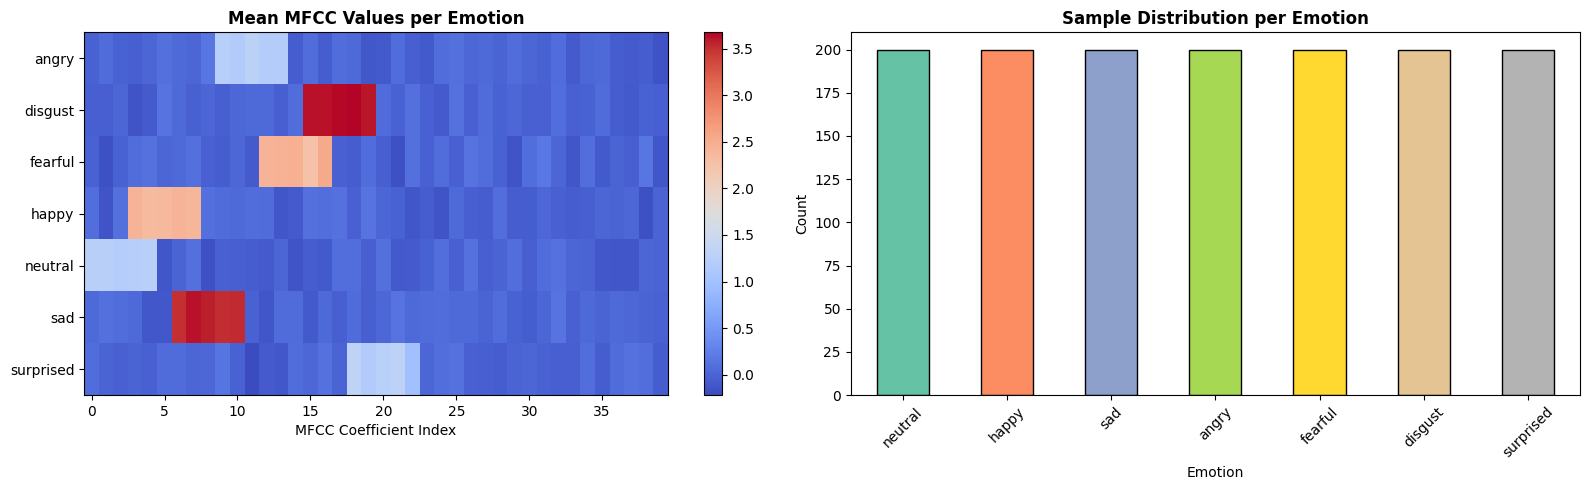

In [3]:
# ─── Visualize Feature Distributions ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# MFCC means per emotion
mfcc_cols = [f'mfcc_{i+1}' for i in range(N_MFCC)]
mfcc_means = df.groupby('emotion')[mfcc_cols].mean()
im = axes[0].imshow(mfcc_means.values, aspect='auto', cmap='coolwarm')
axes[0].set_yticks(range(len(EMOTIONS)))
axes[0].set_yticklabels(mfcc_means.index)
axes[0].set_xlabel('MFCC Coefficient Index')
axes[0].set_title('Mean MFCC Values per Emotion', fontweight='bold')
plt.colorbar(im, ax=axes[0])

# Sample count
colors_ = plt.cm.Set2(np.linspace(0, 1, len(EMOTIONS)))
df['emotion'].value_counts().plot(kind='bar', color=colors_, ax=axes[1], edgecolor='black')
axes[1].set_title('Sample Distribution per Emotion', fontweight='bold')
axes[1].set_xlabel('Emotion'); axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()


In [4]:
# ─── Preprocessing ───────────────────────────────────────────────────────────
le = LabelEncoder()
y_enc = le.fit_transform(y)
num_classes = len(le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# One-hot for Keras
y_train_oh = to_categorical(y_train, num_classes)
y_test_oh  = to_categorical(y_test,  num_classes)

# Reshape for Conv1D → (samples, features, 1)
X_train_cnn = X_train_sc.reshape(X_train_sc.shape[0], X_train_sc.shape[1], 1)
X_test_cnn  = X_test_sc.reshape(X_test_sc.shape[0],  X_test_sc.shape[1],  1)

print(f"Train: {X_train.shape} | Test: {X_test.shape} | Classes: {num_classes}")
print(f"Classes: {list(le.classes_)}")


Train: (1120, 66) | Test: (280, 66) | Classes: 7
Classes: [np.str_('angry'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]


In [5]:
# ─── Build CNN Model ─────────────────────────────────────────────────────────
def build_cnn(input_shape, num_classes):
    model = Sequential([
        Conv1D(64, 3, activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(2),
        Dropout(0.3),

        Conv1D(128, 3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(2),
        Dropout(0.3),

        Conv1D(256, 3, activation='relu', padding='same'),
        BatchNormalization(),
        Flatten(),
        Dropout(0.4),

        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

cnn_model = build_cnn((X_train_cnn.shape[1], 1), num_classes)
cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 66, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 66, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 33, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 33, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 33, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 33, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 16, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,175,943 (4.49 MB)

 Trainable params: 1,175,047 (4.48 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - accuracy: 0.6670 - loss: 1.0456 - val_accuracy: 0.3333 - val_loss: 1.5152
Epoch 2/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9107 - loss: 0.2455 - val_accuracy: 0.4405 - val_loss: 1.5311
Epoch 3/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9433 - loss: 0.1514 - val_accuracy: 0.3869 - val_loss: 1.6609
Epoch 4/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9632 - loss: 0.1482 - val_accuracy: 0.4107 - val_loss: 1.8937
Epoch 5/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9580 - loss: 0.1246 - val_accuracy: 0.6548 - val_loss: 0.9679
Epoch 6/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.9611 - loss: 0.1194 - val_accuracy: 0.6964 - val_loss: 0.8770
Epoch 7/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9779 - loss: 0.0923 - val_accuracy: 0.6667 - val_loss: 0.8744
Epoch 8/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9727 - loss: 0.0761 - val_accuracy: 0.8274 - v

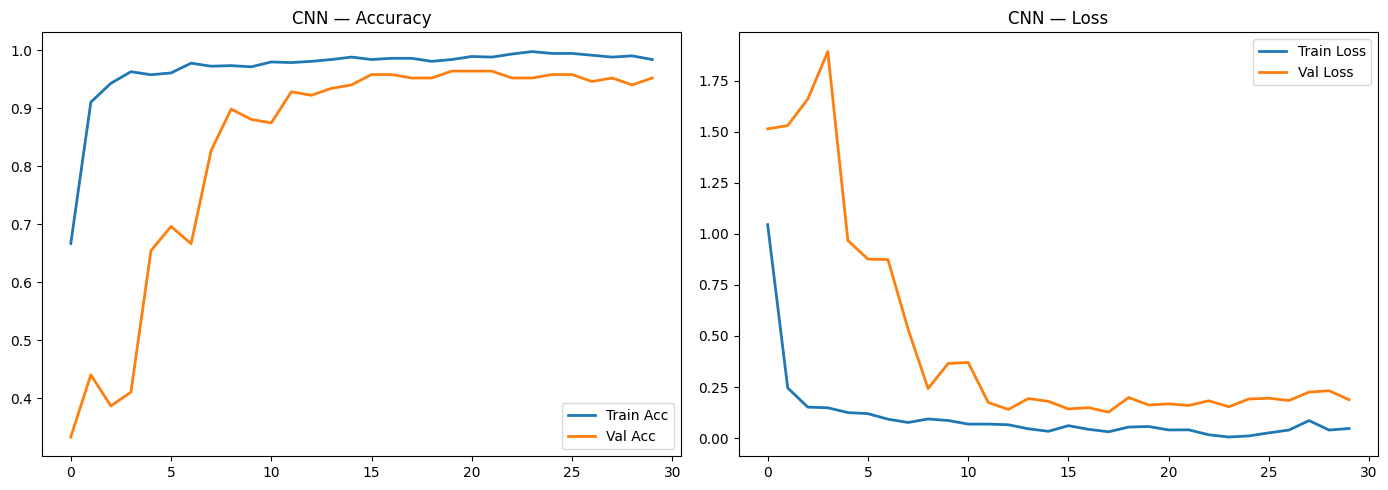

In [6]:
# ─── Train CNN ───────────────────────────────────────────────────────────────
es = EarlyStopping(patience=10, restore_best_weights=True, monitor='val_accuracy')

history = cnn_model.fit(
    X_train_cnn, y_train_oh,
    validation_split=0.15,
    epochs=60,
    batch_size=32,
    callbacks=[es],
    verbose=1
)

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'],     label='Train Acc', lw=2)
axes[0].plot(history.history['val_accuracy'], label='Val Acc',   lw=2)
axes[0].set_title('CNN — Accuracy'); axes[0].legend()
axes[1].plot(history.history['loss'],     label='Train Loss', lw=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   lw=2)
axes[1].set_title('CNN — Loss'); axes[1].legend()
plt.tight_layout(); plt.show()



🧠 CNN Test Accuracy: 0.9321

              precision    recall  f1-score   support

       angry       0.81      0.88      0.84        40
     disgust       1.00      1.00      1.00        40
     fearful       0.98      1.00      0.99        40
       happy       0.97      0.97      0.97        40
     neutral       0.92      0.82      0.87        40
         sad       0.98      1.00      0.99        40
   surprised       0.87      0.85      0.86        40

    accuracy                           0.93       280
   macro avg       0.93      0.93      0.93       280
weighted avg       0.93      0.93      0.93       280

  SVM (RBF)           : 0.9393
  Random Forest       : 0.9393
  MLP                 : 0.9250


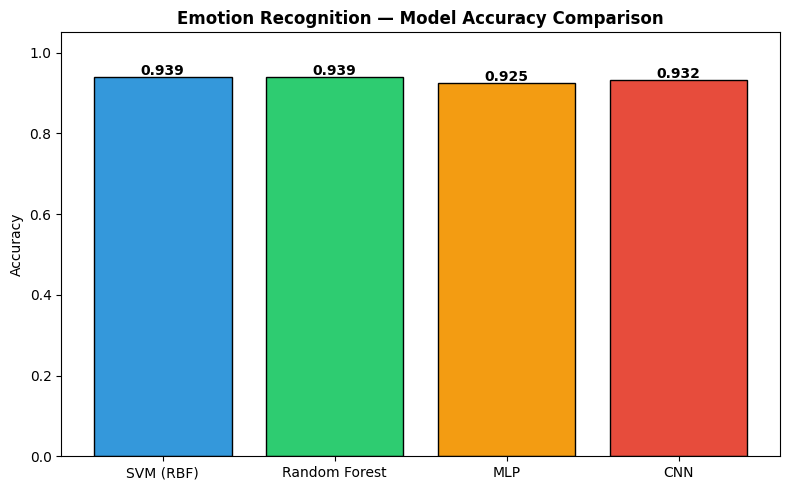

In [7]:
# ─── Evaluate & Compare Models ───────────────────────────────────────────────
# CNN evaluation
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test_oh, verbose=0)
y_pred_cnn = np.argmax(cnn_model.predict(X_test_cnn, verbose=0), axis=1)

print(f"\n🧠 CNN Test Accuracy: {cnn_acc:.4f}\n")
print(classification_report(y_test, y_pred_cnn, target_names=le.classes_))

# Compare classical ML
clf_models = {
    'SVM (RBF)':      SVC(kernel='rbf', probability=True, random_state=42),
    'Random Forest':  RandomForestClassifier(n_estimators=150, random_state=42),
    'MLP':            MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=300, random_state=42),
}
classical_acc = {}
for name, clf in clf_models.items():
    clf.fit(X_train_sc, y_train)
    acc = clf.score(X_test_sc, y_test)
    classical_acc[name] = acc
    print(f"  {name:20s}: {acc:.4f}")
classical_acc['CNN'] = cnn_acc

# Bar chart comparison
plt.figure(figsize=(8, 5))
names_ = list(classical_acc.keys())
accs_  = [classical_acc[n] for n in names_]
colors_ = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
bars = plt.bar(names_, accs_, color=colors_, edgecolor='black')
for bar, acc in zip(bars, accs_):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', fontweight='bold')
plt.title('Emotion Recognition — Model Accuracy Comparison', fontweight='bold')
plt.ylabel('Accuracy'); plt.ylim(0.0, 1.05)
plt.tight_layout(); plt.show()


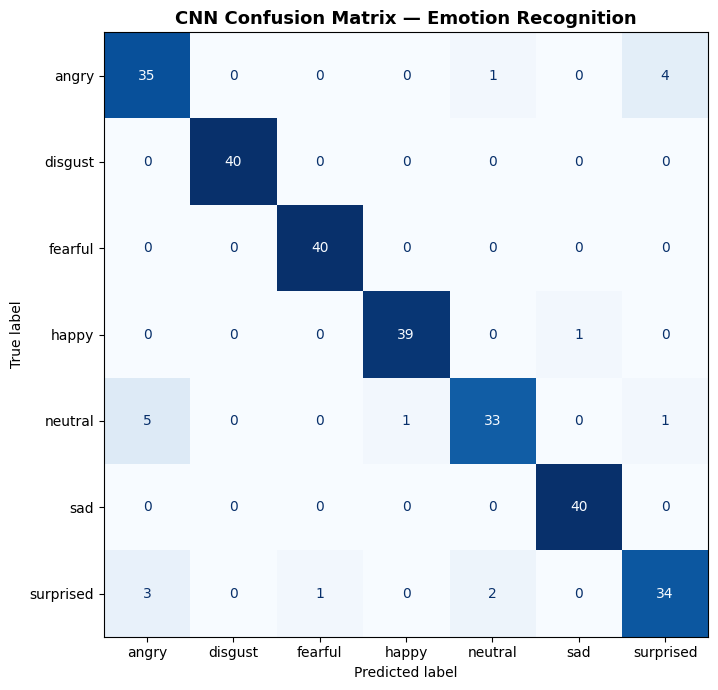

In [8]:
# ─── Confusion Matrix ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_cnn,
    display_labels=le.classes_,
    cmap='Blues', ax=ax, colorbar=False)
ax.set_title('CNN Confusion Matrix — Emotion Recognition', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()
